# Model Deep Dive — How Spatial Omics Fusion Works and Learns

This notebook provides a detailed walkthrough of the **model architecture** and **training process**. We trace a single forward pass through every component, visualize the intermediate tensor shapes and learned representations, and explain how the model learns.

**Sections**:
1. **Setup & Data** — Load one slice and the trained model
2. **Expression Encoder (MLP)** — How gene expression gets compressed
3. **Spatial Encoder (GAT)** — How Graph Attention Networks aggregate neighbors
4. **Fusion** — How cross-attention and gated fusion combine the two streams
5. **Training** — Loss function, class weighting, early stopping, and learning curves
6. **What the Model Learned** — Interpreting weights and attention patterns

In [1]:
import os, sys, json
import warnings
warnings.filterwarnings('ignore')
import dask
dask.config.set({'dataframe.query-planning': True})

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
from scipy.sparse import issparse
from sklearn.manifold import TSNE
import yaml

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.data.dataset import load_dlpfc_data
from src.models.model import SpatialOmicsFusion
from src.models.expression_encoder import ExpressionEncoder
from src.models.spatial_encoder import SpatialEncoder
from src.models.fusion import CrossAttentionFusion, GatedFusion

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

SAMPLE_ID = '151673'
DOMAIN_COLORS = ['#E41A1C', '#FF7F00', '#FFD700', '#4DAF4A', '#377EB8', '#984EA3', '#A65628']
DOMAIN_NAMES = ['Layer1', 'Layer2', 'Layer3', 'Layer4', 'Layer5', 'Layer6', 'WM']

# Load data and config
data = load_dlpfc_data(SAMPLE_ID, processed_dir='../data/processed', seed=42)
with open('../configs/default.yaml') as f:
    config = yaml.safe_load(f)

coords = data.pos.numpy()
labels = data.y.numpy()
n_classes = data.n_classes

# Load trained model
def load_model(mode, fusion_type):
    model = SpatialOmicsFusion(
        n_genes=data.x.shape[1], n_classes=data.n_classes,
        embed_dim=config['model']['embed_dim'],
        hidden_dim=config['model']['expression_encoder']['hidden_dim'],
        expr_layers=config['model']['expression_encoder']['n_layers'],
        gat_heads=config['model']['spatial_encoder']['n_heads'],
        gat_layers=config['model']['spatial_encoder']['n_layers'],
        fusion_type=fusion_type,
        fusion_heads=config['model']['fusion']['n_heads'],
        fusion_layers=config['model']['fusion']['n_layers'],
        dropout=0.0, mode=mode,
    )
    state = torch.load(f'../results/{mode}_{fusion_type}_{SAMPLE_ID}/model.pt',
                       map_location='cpu', weights_only=True)
    model.load_state_dict(state)
    model.eval()
    return model

model = load_model('full', 'cross_attention')
model_gated = load_model('full', 'gated')
print(f'Data:  {data.x.shape[0]} spots, {data.x.shape[1]} genes, {n_classes} classes')
print(f'Graph: {data.edge_index.shape[1]} edges (k=6)')
print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters')

Data:  3611 spots, 3000 genes, 7 classes
Graph: 21666 edges (k=6)
Model: 1,107,063 parameters


---
# 1. Expression Encoder (MLP)

The first component takes a spot's raw gene expression vector (3,000 HVGs) and compresses it to a 128-dim embedding.

### Architecture
```
Input: gene expression vector (3000,)
    |
    +- LayerNorm(3000)          <- stabilize input distribution
    |
    +- Linear(3000 -> 256)      <- compress to hidden dim
    +- GELU activation          <- nonlinearity
    +- Dropout(0.1)             <- regularization
    |
    +- Linear(256 -> 128)       <- compress to embedding dim
    |
Output: expression embedding (128,)
```

### Why this design?
- **LayerNorm first**: Even though the input is z-scored, LayerNorm adds learnable scale/shift parameters that the model can tune during training.
- **GELU activation**: Smoother than ReLU, works well in transformer-style architectures. It allows small negative values through (unlike ReLU which hard-zeros them).
- **Two layers**: One hidden layer (256-dim) gives the model a chance to learn nonlinear gene-gene interactions before compressing to 128-dim. A single layer would only learn linear combinations.
- **No activation on the last layer**: The output embedding should be unconstrained -- it feeds into both the GAT and the classifier.

### What it learns
The MLP learns which **combinations of genes** are informative for layer identity. For example, it might learn that "high gene A + low gene B" is a strong indicator of Layer 5. These patterns are compressed into 128 numbers -- the expression embedding.

In [2]:
# Trace through the Expression Encoder step by step
x = data.x  # (3611, 3000)
print(f'Input:  {x.shape}  -- raw gene expression (z-scored)')
print(f'        min={x.min():.2f}, max={x.max():.2f}, mean={x.mean():.4f}')

with torch.no_grad():
    # Step 1: LayerNorm
    x_normed = model.expr_encoder.norm(x)
    print(f'\nAfter LayerNorm: {x_normed.shape}')
    print(f'        min={x_normed.min():.2f}, max={x_normed.max():.2f}, mean={x_normed.mean():.4f}')

    # Step 2: Full MLP
    expr_embed = model.expr_encoder(x)
    print(f'\nOutput: {expr_embed.shape}  -- expression embedding')
    print(f'        min={expr_embed.min():.2f}, max={expr_embed.max():.2f}, mean={expr_embed.mean():.4f}')

Input:  torch.Size([3611, 3000])  -- raw gene expression (z-scored)
        min=-10.00, max=10.00, mean=-0.0077

After LayerNorm: torch.Size([3611, 3000])
        min=-8.14, max=18.53, mean=-0.0006

Output: torch.Size([3611, 128])  -- expression embedding
        min=-4.73, max=4.28, mean=0.0219


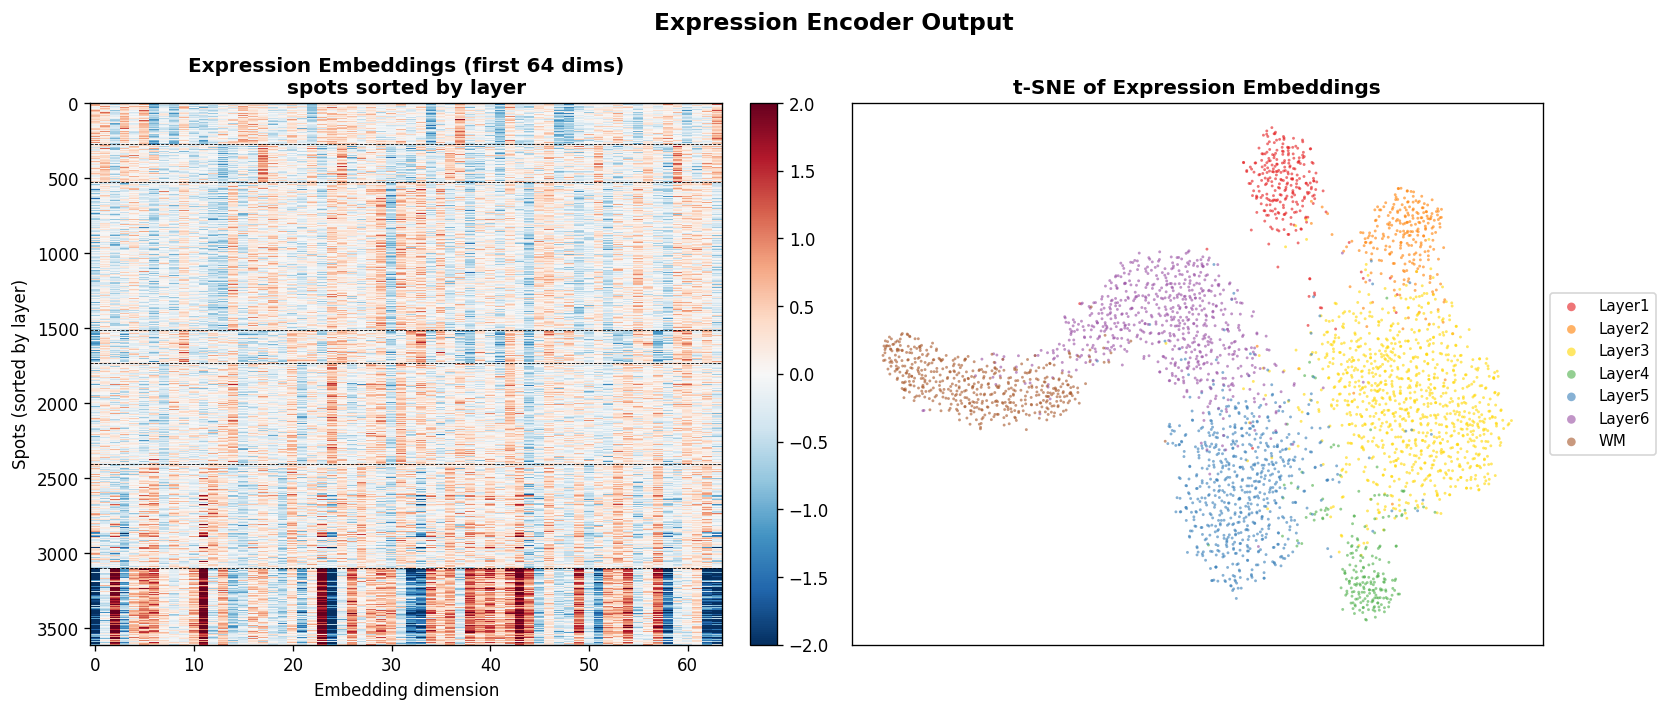

In [3]:
# Visualize: what does the MLP output look like?
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: expression embedding heatmap (spots sorted by label)
sorted_idx = np.argsort(labels)
im = axes[0].imshow(expr_embed.numpy()[sorted_idx, :64], aspect='auto', cmap='RdBu_r',
                     interpolation='nearest', vmin=-2, vmax=2)
axes[0].set_title('Expression Embeddings (first 64 dims)\nspots sorted by layer', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Embedding dimension')
axes[0].set_ylabel('Spots (sorted by layer)')
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

# Add layer boundaries
cumcounts = np.cumsum([np.sum(labels == i) for i in range(n_classes)])
for c in cumcounts[:-1]:
    axes[0].axhline(y=c, color='black', linewidth=0.5, linestyle='--')

# Right: t-SNE of expression embeddings
tsne = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(expr_embed.numpy())
for i in range(n_classes):
    mask = labels == i
    axes[1].scatter(tsne[mask, 0], tsne[mask, 1], c=DOMAIN_COLORS[i],
                    label=DOMAIN_NAMES[i], s=3, alpha=0.6, edgecolors='none')
axes[1].set_title('t-SNE of Expression Embeddings', fontsize=12, fontweight='bold')
axes[1].set_xticks([]); axes[1].set_yticks([])
axes[1].legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9, markerscale=3)

plt.suptitle('Expression Encoder Output', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Reading the plots above

**Left (heatmap)**: Each row is a spot (sorted by ground truth layer), each column is one embedding dimension. If the MLP has learned good representations, you should see **horizontal bands** -- groups of spots from the same layer having similar embedding values. Visible but noisy bands indicate the MLP captures some layer signal, but with significant overlap.

**Right (t-SNE)**: The 128-dim embeddings projected to 2D. Some layer clusters are visible, but there is substantial overlap -- especially between adjacent layers (Layer 2/3, Layer 5/6). This is expected: gene expression alone provides a noisy signal for layer identity. The GAT will resolve much of this ambiguity using spatial context.

---
# 2. Spatial Encoder (GAT)

The Graph Attention Network takes the expression embeddings and the spatial KNN graph, and produces **spatially-aware embeddings** by aggregating information from each spot's neighbors.

### What is a Graph Attention Network?

A regular neural network processes each data point independently. A GNN processes data points **in the context of their graph neighbors**. A GAT specifically uses **attention** to decide how much weight to give each neighbor.

For each spot i with neighbors N(i), one GAT layer computes:

```
For each neighbor j:
    alpha_ij = softmax_j( LeakyReLU( a^T [W*h_i || W*h_j] ) )   <- attention coefficient

h_i_new = SUM_j  alpha_ij * W * h_j                              <- weighted sum of neighbor features
```

In plain English:
1. **Project** both the spot and each neighbor's features through a weight matrix W
2. **Score** each neighbor's relevance using a learned attention vector a
3. **Softmax** the scores so they sum to 1 across all neighbors
4. **Aggregate**: the spot's new embedding is the weighted sum of its neighbors' projected features

### Multi-head attention
We use **4 attention heads**, each with 32 dimensions (128 / 4 = 32). Each head can learn to attend to neighbors for a different reason. The outputs are concatenated back to 128-dim.

### Our architecture
```
Input: expression embeddings (3611, 128) + edge_index (2, 21666)
    |
    +- GATConv Layer 1 (128 -> 128, 4 heads x 32 dims)
    +- LayerNorm + ELU + Dropout + Residual
    |
    +- GATConv Layer 2 (128 -> 128, 4 heads x 32 dims)
    +- LayerNorm + ELU + Dropout + Residual
    |
Output: spatial embeddings (3611, 128)
```

### What it learns
After two GAT layers, each spot's embedding encodes not just its own expression, but a **weighted summary of its neighborhood**. Two rounds of aggregation means each spot "sees" up to 2-hop neighbors (neighbors of neighbors). With k=6, this covers ~30-40 spots around each position.

The attention mechanism lets the model learn: "When aggregating, pay more attention to neighbors that are similar to me and less to those that are different." This is especially powerful at domain boundaries.

In [4]:
# Trace through the GAT step by step
with torch.no_grad():
    gat = model.spatial_encoder
    x_in = expr_embed.clone()

    print(f'GAT Input:  {x_in.shape}  -- expression embeddings')
    print(f'Graph:      {data.edge_index.shape}  -- {data.edge_index.shape[1]} edges')
    print(f'\n--- Layer 1 ---')

    x1_raw = gat.convs[0](x_in, data.edge_index)
    print(f'After GATConv:  {x1_raw.shape}  (4 heads x 32 dims = 128)')

    x1_norm = gat.norms[0](x1_raw)
    x1_act = torch.nn.functional.elu(x1_norm)
    x1_out = x1_act + x_in  # residual
    print(f'After Norm+ELU+Residual: {x1_out.shape}')

    print(f'\n--- Layer 2 ---')
    x2_raw = gat.convs[1](x1_out, data.edge_index)
    x2_norm = gat.norms[1](x2_raw)
    x2_act = torch.nn.functional.elu(x2_norm)
    spatial_embed = x2_act + x1_out  # residual
    print(f'After Norm+ELU+Residual: {spatial_embed.shape}')

    print(f'\nFinal spatial embedding: {spatial_embed.shape}')
    print(f'min={spatial_embed.min():.2f}, max={spatial_embed.max():.2f}, mean={spatial_embed.mean():.4f}')

GAT Input:  torch.Size([3611, 128])  -- expression embeddings
Graph:      torch.Size([2, 21666])  -- 21666 edges

--- Layer 1 ---
After GATConv:  torch.Size([3611, 128])  (4 heads x 32 dims = 128)
After Norm+ELU+Residual: torch.Size([3611, 128])

--- Layer 2 ---
After Norm+ELU+Residual: torch.Size([3611, 128])

Final spatial embedding: torch.Size([3611, 128])
min=-5.46, max=7.17, mean=0.3351


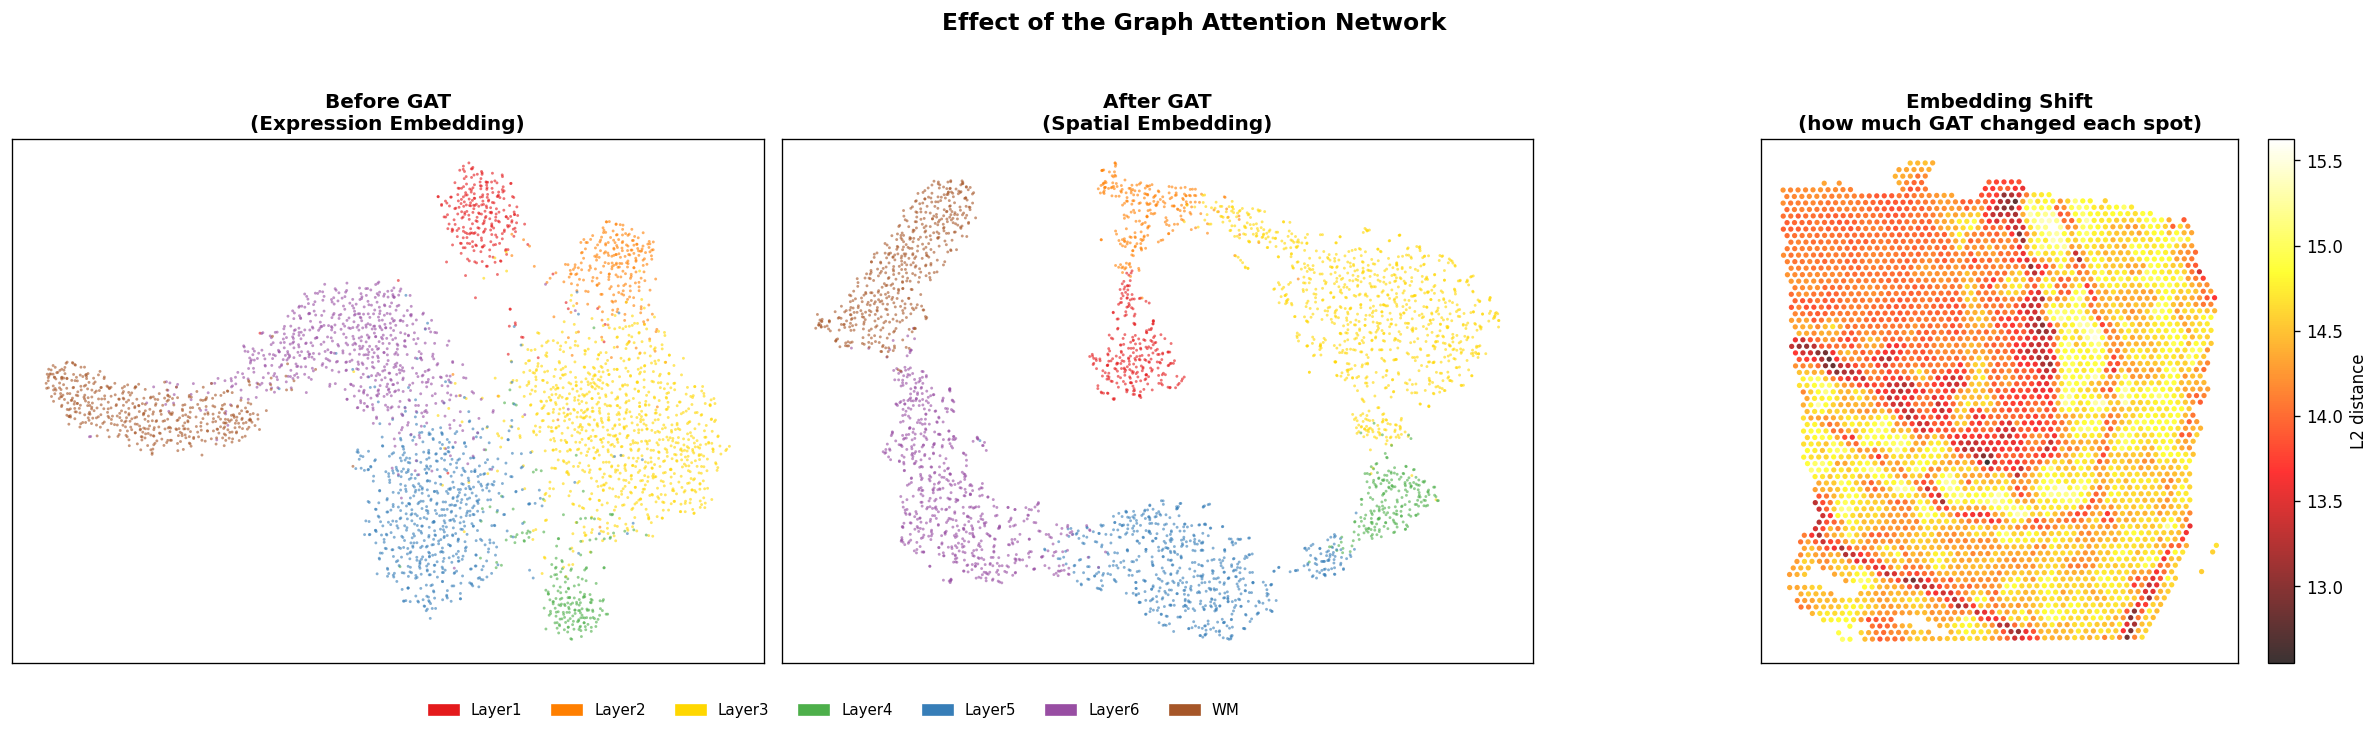

In [5]:
# Compare: expression embedding vs spatial embedding
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Left: expression embedding t-SNE (already computed)
for i in range(n_classes):
    mask = labels == i
    axes[0].scatter(tsne[mask, 0], tsne[mask, 1], c=DOMAIN_COLORS[i],
                    label=DOMAIN_NAMES[i], s=3, alpha=0.6, edgecolors='none')
axes[0].set_title('Before GAT\n(Expression Embedding)', fontsize=12, fontweight='bold')
axes[0].set_xticks([]); axes[0].set_yticks([])

# Middle: spatial embedding t-SNE
tsne_spatial = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(spatial_embed.numpy())
for i in range(n_classes):
    mask = labels == i
    axes[1].scatter(tsne_spatial[mask, 0], tsne_spatial[mask, 1], c=DOMAIN_COLORS[i],
                    s=3, alpha=0.6, edgecolors='none')
axes[1].set_title('After GAT\n(Spatial Embedding)', fontsize=12, fontweight='bold')
axes[1].set_xticks([]); axes[1].set_yticks([])

# Right: how much did each spot's embedding change?
embedding_shift = torch.norm(spatial_embed - expr_embed, dim=1).numpy()
sc_plot = axes[2].scatter(coords[:, 0], coords[:, 1], c=embedding_shift, cmap='hot',
                           s=10, alpha=0.8, edgecolors='none')
axes[2].set_title('Embedding Shift\n(how much GAT changed each spot)', fontsize=12, fontweight='bold')
axes[2].set_aspect('equal'); axes[2].invert_yaxis()
axes[2].set_xticks([]); axes[2].set_yticks([])
plt.colorbar(sc_plot, ax=axes[2], fraction=0.046, pad=0.04, label='L2 distance')

handles = [mpatches.Patch(color=DOMAIN_COLORS[i], label=DOMAIN_NAMES[i]) for i in range(n_classes)]
fig.legend(handles=handles, loc='lower center', ncol=n_classes, fontsize=9, frameon=False,
           bbox_to_anchor=(0.35, -0.02))
plt.suptitle('Effect of the Graph Attention Network', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Reading the plots above

**Left vs Middle**: The dramatic improvement in cluster separation shows the power of spatial aggregation. The GAT transforms noisy, overlapping expression clusters into well-separated groups. This is the biggest single improvement in our pipeline (ARI: 0.37 -> 0.92).

**Right (embedding shift)**: The heatmap shows how much the GAT changed each spot's embedding (L2 distance between expression and spatial embeddings). Spots at **domain boundaries** tend to have larger shifts -- the GAT most strongly modifies embeddings where spatial context provides the most disambiguating information. Interior spots that are already clearly one layer need less adjustment.

---
# 3. Fusion: Combining Expression and Spatial Streams

After the MLP and GAT, we have two 128-dim embeddings per spot:
- **Expression embedding**: What this spot looks like molecularly (from MLP)
- **Spatial embedding**: What this spot and its neighbors look like (from GAT)

The **fusion module** combines these into a single embedding for classification. We implemented two strategies:

### Strategy 1: Gated Fusion (simple)
```
gate = sigmoid(W * [expression; spatial])     <- per-spot gate in [0, 1]
output = gate * expression + (1-gate) * spatial
```
A learned weighted average -- the model decides per-spot how much to trust each modality. Simple and interpretable, but the weighting is the same regardless of which neighbors are involved.

### Strategy 2: Cross-Attention Fusion (our best)
```
For each spot:
    Q = expression embedding          <- "what am I looking for?"
    K, V = spatial embeddings of      <- "what do my neighbors offer?"
           graph neighbors

    output = softmax(Q * K^T / sqrt(d)) * V    <- selectively attend to relevant neighbors
```

This is a **transformer-style cross-attention** mechanism. The key difference from gated fusion: instead of a fixed weighting, the model can **selectively attend to specific neighbors** based on how relevant they are to the query spot's expression profile.

Think of it as: "Given my gene expression pattern, which of my spatial neighbors should I listen to most?"

### Why cross-attention wins
At domain boundaries, a spot might have neighbors from two different layers. Gated fusion treats spatial information as a single vector -- it cannot distinguish between neighbors. Cross-attention can learn to attend to the 4 neighbors that look like Layer 3 and ignore the 2 that look like Layer 4.

In [6]:
# === Cross-Attention Fusion: step by step ===
with torch.no_grad():
    fusion = model.fusion  # CrossAttentionFusion
    N = expr_embed.shape[0]

    # Step 1: Build neighbor index from the graph
    neighbor_idx, attn_mask = fusion._build_neighbor_index(data.edge_index, N, expr_embed.device)
    print(f'Neighbor index: {neighbor_idx.shape}  -- (spots, max_neighbors)')
    print(f'Attention mask:  {attn_mask.shape}  -- True where padded (no neighbor)')
    print(f'Max neighbors per spot: {(~attn_mask).sum(dim=1).max().item()}')

    # Step 2: Gather neighbor spatial embeddings
    kv = spatial_embed[neighbor_idx]  # (N, max_neighbors, 128)
    q = expr_embed.unsqueeze(1)       # (N, 1, 128)
    print(f'\nQuery (expression): {q.shape}  -- one query per spot')
    print(f'Key/Value (spatial): {kv.shape}  -- neighbor spatial embeddings')

    # Step 3: Cross-attention (layer 1)
    attn_out, attn_weights_raw = fusion.cross_attns[0](
        q, kv, kv, key_padding_mask=attn_mask, need_weights=True, average_attn_weights=True
    )
    print(f'\nAttention output: {attn_out.shape}')
    print(f'Attention weights: {attn_weights_raw.shape}  -- weight per neighbor per spot')

    # Step 4: Residual + LayerNorm + FFN (transformer block)
    x = fusion.norm1s[0](expr_embed + fusion.dropout(attn_out.squeeze(1)))
    x = fusion.norm2s[0](x + fusion.dropout(fusion.ffns[0](x)))
    print(f'\nAfter layer 1 (residual+norm+FFN): {x.shape}')

    # Full fusion output (both layers)
    fused_embed = fusion(expr_embed, spatial_embed, data.edge_index)
    print(f'\nFinal fused embedding: {fused_embed.shape}')

Neighbor index: torch.Size([3611, 10])  -- (spots, max_neighbors)
Attention mask:  torch.Size([3611, 10])  -- True where padded (no neighbor)
Max neighbors per spot: 10

Query (expression): torch.Size([3611, 1, 128])  -- one query per spot
Key/Value (spatial): torch.Size([3611, 10, 128])  -- neighbor spatial embeddings

Attention output: torch.Size([3611, 1, 128])
Attention weights: torch.Size([3611, 1, 10])  -- weight per neighbor per spot

After layer 1 (residual+norm+FFN): torch.Size([3611, 128])

Final fused embedding: torch.Size([3611, 128])


In [7]:
# === Gated Fusion: step by step ===
with torch.no_grad():
    expr_g = model_gated.expr_encoder(data.x)
    spatial_g = model_gated.spatial_encoder(expr_g, data.edge_index)

    # Step 1: Concatenate both embeddings
    concat = torch.cat([expr_g, spatial_g], dim=-1)  # (N, 256)
    print(f'Concatenated: {concat.shape}  -- [expression; spatial]')

    # Step 2: Compute gate
    gate_values = model_gated.fusion.gate(concat)  # (N, 128) -- sigmoid output
    print(f'Gate values:  {gate_values.shape}  -- values in [0, 1]')
    print(f'Gate mean: {gate_values.mean():.3f}, std: {gate_values.std():.3f}')

    # Step 3: Weighted combination
    fused_g = gate_values * expr_g + (1 - gate_values) * spatial_g
    print(f'\nGated output: {fused_g.shape}')

    # Step 4: FFN + LayerNorm
    fused_gated = model_gated.fusion(expr_g, spatial_g)
    print(f'After FFN+Norm: {fused_gated.shape}')

Concatenated: torch.Size([3611, 256])  -- [expression; spatial]
Gate values:  torch.Size([3611, 128])  -- values in [0, 1]
Gate mean: 0.489, std: 0.175

Gated output: torch.Size([3611, 128])
After FFN+Norm: torch.Size([3611, 128])


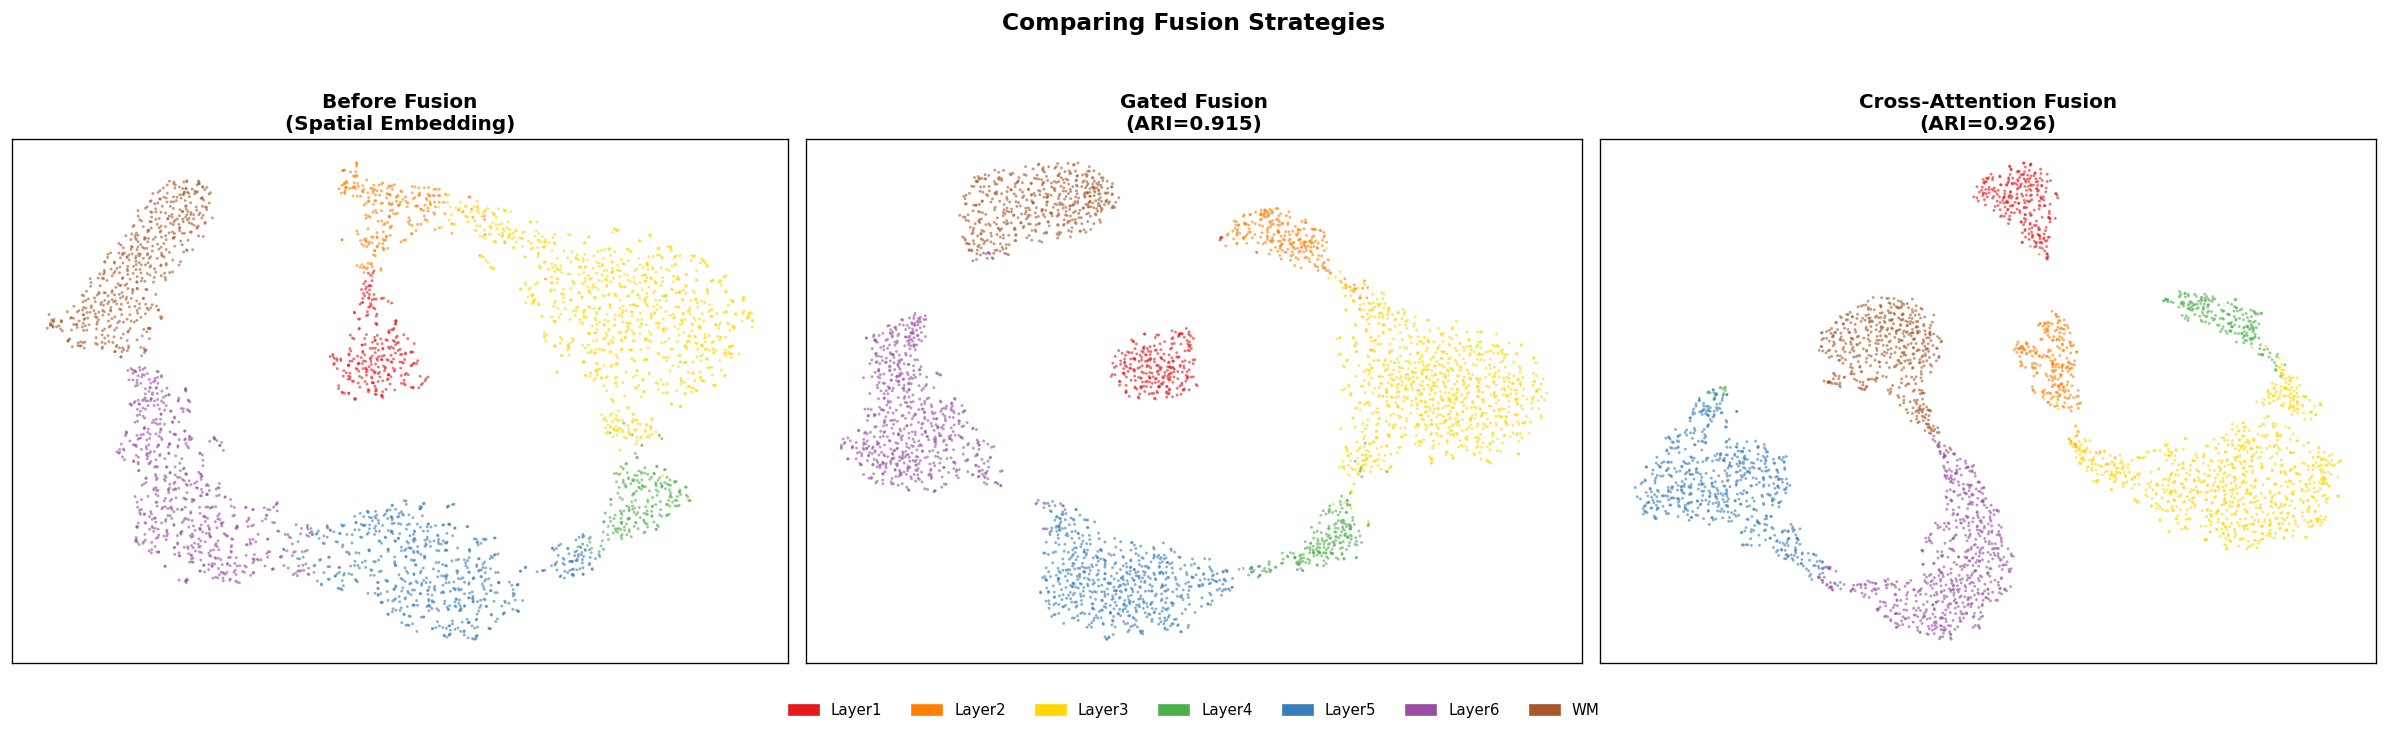

In [8]:
# Compare fusion outputs
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# t-SNE of spatial embedding (before fusion)
for i in range(n_classes):
    mask = labels == i
    axes[0].scatter(tsne_spatial[mask, 0], tsne_spatial[mask, 1], c=DOMAIN_COLORS[i],
                    s=3, alpha=0.6, edgecolors='none')
axes[0].set_title('Before Fusion\n(Spatial Embedding)', fontsize=12, fontweight='bold')
axes[0].set_xticks([]); axes[0].set_yticks([])

# t-SNE of gated fusion
tsne_gated = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(fused_gated.numpy())
for i in range(n_classes):
    mask = labels == i
    axes[1].scatter(tsne_gated[mask, 0], tsne_gated[mask, 1], c=DOMAIN_COLORS[i],
                    s=3, alpha=0.6, edgecolors='none')
axes[1].set_title('Gated Fusion\n(ARI=0.915)', fontsize=12, fontweight='bold')
axes[1].set_xticks([]); axes[1].set_yticks([])

# t-SNE of cross-attention fusion
tsne_fused = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(fused_embed.numpy())
for i in range(n_classes):
    mask = labels == i
    axes[2].scatter(tsne_fused[mask, 0], tsne_fused[mask, 1], c=DOMAIN_COLORS[i],
                    s=3, alpha=0.6, edgecolors='none')
axes[2].set_title('Cross-Attention Fusion\n(ARI=0.926)', fontsize=12, fontweight='bold')
axes[2].set_xticks([]); axes[2].set_yticks([])

handles = [mpatches.Patch(color=DOMAIN_COLORS[i], label=DOMAIN_NAMES[i]) for i in range(n_classes)]
fig.legend(handles=handles, loc='lower center', ncol=n_classes, fontsize=9, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Comparing Fusion Strategies', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

### Reading the plots above

Both fusion strategies improve over the spatial embedding alone, but the differences are subtle in t-SNE (t-SNE can exaggerate or hide small differences). The real improvement shows up in ARI scores across 12 slices: cross-attention (0.926) consistently outperforms gated (0.915), especially at domain boundaries where selective neighbor attention matters most.

---
# 4. Classification Head

The simplest component -- a single linear layer that maps the 128-dim fused embedding to 7 class logits:

```
Linear(128 -> 7)    -> logits (unnormalized scores per class)
    |
softmax -> probabilities (for prediction: argmax)
    |
CrossEntropyLoss (for training: combines softmax + log-loss)
```

No hidden layers, no activation -- this forces all the representational learning into the embedding. If the fused embedding is good enough (well-separated clusters), a linear classifier is sufficient. This is a common design pattern: learn a powerful representation, then classify with a simple head.

In [9]:
# Classification: from embedding to prediction
with torch.no_grad():
    logits = model.classifier(fused_embed)  # (3611, 7)
    probs = torch.softmax(logits, dim=-1)
    preds = logits.argmax(dim=-1)

    print(f'Fused embedding: {fused_embed.shape}')
    print(f'Logits:          {logits.shape}  -- one score per class')
    print(f'Probabilities:   {probs.shape}  -- softmax of logits')
    print(f'Predictions:     {preds.shape}  -- argmax')

    # Show example: one spot from each layer
    print(f'\n{"Spot":>6} {"True":>8} {"Pred":>8} {"Confidence":>12}  Class Probabilities')
    print('-' * 75)
    for cls in range(n_classes):
        idx = (labels == cls).nonzero()[0][0]
        prob_str = '  '.join(f'{p:.2f}' for p in probs[idx])
        conf = probs[idx, preds[idx]].item()
        correct = 'Y' if preds[idx] == labels[idx] else 'N'
        print(f'{idx:6d} {DOMAIN_NAMES[labels[idx]]:>8} {DOMAIN_NAMES[preds[idx]]:>8} {conf:>10.1%}  {correct}  [{prob_str}]')

Fused embedding: torch.Size([3611, 128])
Logits:          torch.Size([3611, 7])  -- one score per class
Probabilities:   torch.Size([3611, 7])  -- softmax of logits
Predictions:     torch.Size([3611])  -- argmax

  Spot     True     Pred   Confidence  Class Probabilities
---------------------------------------------------------------------------
     1   Layer1   Layer1      99.0%  Y  [0.99  0.00  0.00  0.00  0.00  0.00  0.00]
     8   Layer2   Layer2      98.9%  Y  [0.00  0.99  0.00  0.00  0.00  0.00  0.00]
     0   Layer3   Layer3      99.2%  Y  [0.00  0.00  0.99  0.00  0.00  0.00  0.00]
    11   Layer4   Layer4      97.4%  Y  [0.00  0.00  0.02  0.97  0.00  0.00  0.00]
     4   Layer5   Layer5      97.8%  Y  [0.00  0.00  0.00  0.00  0.98  0.01  0.00]
     5   Layer6   Layer6      98.1%  Y  [0.00  0.01  0.00  0.00  0.00  0.98  0.00]
     2       WM       WM      98.8%  Y  [0.00  0.00  0.00  0.00  0.00  0.00  0.99]


### Reading the table above

Each row shows one example spot per layer. The "Class Probabilities" column shows the softmax output -- the model's confidence for each of the 7 classes. A well-trained model should show:
- **High confidence** (>90%) for most spots -- the fused embedding puts them clearly in one cluster
- **Lower confidence at boundaries** -- spots between two layers may have split probability between adjacent classes
- **Correct predictions** -- even when confidence is not 100%, the highest probability should match ground truth

---
# 5. How the Model Learns

### Training setup

| Component | Choice | Why |
|---|---|---|
| **Loss** | CrossEntropyLoss | Standard for multi-class classification |
| **Class weighting** | Inverse frequency | Layer4 has 218 spots, Layer3 has 989 -- without weighting, the model would ignore minority classes |
| **Optimizer** | AdamW (lr=1e-3, wd=1e-4) | Adam with decoupled weight decay -- standard for transformers |
| **LR schedule** | ReduceLROnPlateau (patience=10) | Halve LR when validation ARI stops improving |
| **Early stopping** | patience=20 on validation ARI | Stop when the model has not improved in 20 epochs |
| **Batch size** | Full-batch (entire graph) | The graph fits in memory (~3,600 nodes). Full-batch avoids the complexities of mini-batch GNN training (neighbor sampling) |

### Class weighting explained

Without weighting, the loss function treats every spot equally. Since Layer3 has ~4.5x more spots than Layer4, the model could get decent accuracy by just being good at Layer3 and ignoring Layer4.

**Inverse frequency weighting** assigns higher loss to minority classes:
```python
weight[class_i] = 1 / count[class_i]    # rare classes get higher weight
weight = weight / sum(weight) * n_classes    # normalize so weights average to 1
```

This forces the model to care equally about every class regardless of frequency.

### Full-batch vs mini-batch

Most deep learning uses mini-batches (randomly sample 32-256 data points per step). Graph data is different: nodes share edges, so you cannot easily batch them independently. Options:
1. **Full-batch**: Forward-pass the entire graph every step. Simple, no sampling artifacts. Only works if the graph fits in GPU memory.
2. **Mini-batch with neighbor sampling**: Sample subgraphs. Necessary for large graphs (millions of nodes), but adds complexity and approximation error.

Our graph has only ~3,600 nodes and ~21,000 edges -- it fits easily in memory, so full-batch is the clear choice. This also means **every training step sees the complete graph structure**, which is especially important for the cross-attention fusion.

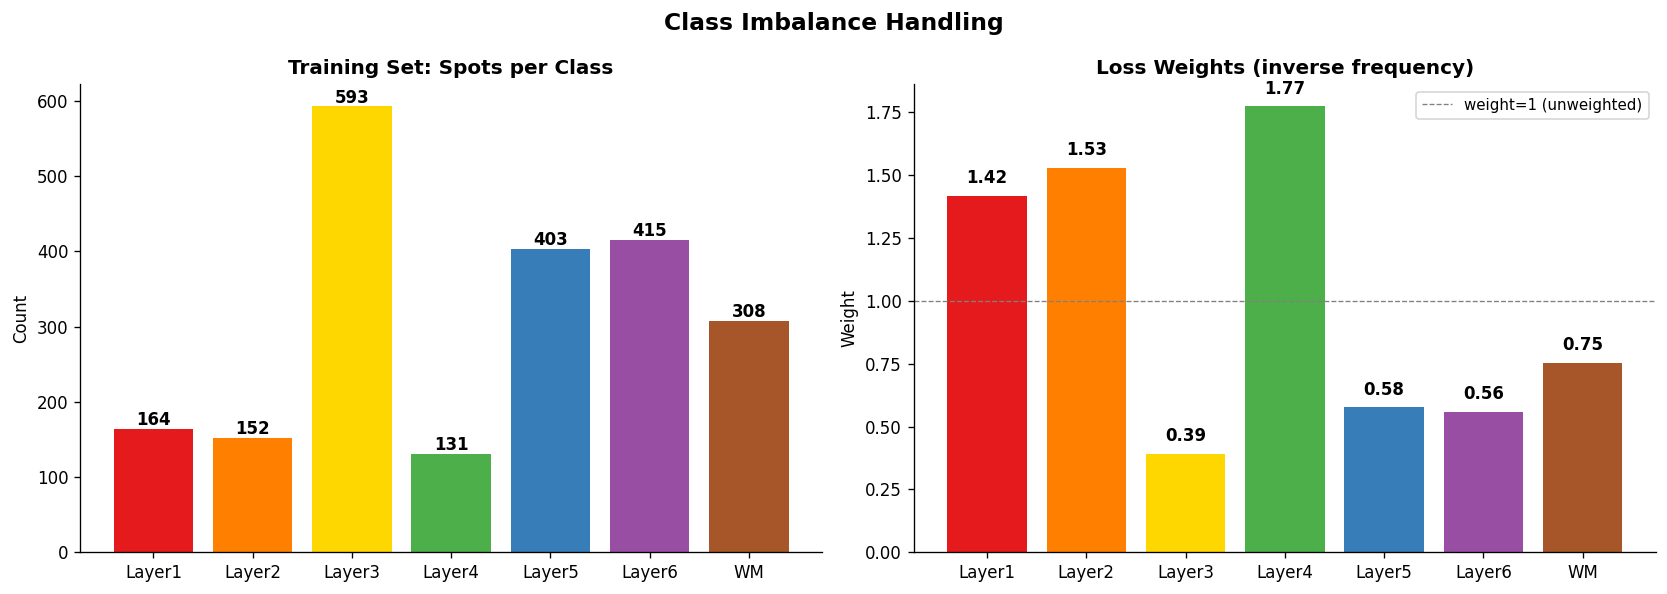

In [10]:
# Visualize: class weighting
class_counts = torch.bincount(data.y[data.train_mask], minlength=n_classes).float()
class_weights = 1.0 / (class_counts + 1e-6)
class_weights = class_weights / class_weights.sum() * n_classes

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: class distribution
bars1 = axes[0].bar(DOMAIN_NAMES, class_counts.numpy(), color=DOMAIN_COLORS)
axes[0].set_title('Training Set: Spots per Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, c in zip(bars1, class_counts.numpy()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{int(c)}', ha='center', fontsize=10, fontweight='bold')

# Right: resulting weights
bars2 = axes[1].bar(DOMAIN_NAMES, class_weights.numpy(), color=DOMAIN_COLORS)
axes[1].set_title('Loss Weights (inverse frequency)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Weight')
axes[1].axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8, label='weight=1 (unweighted)')
axes[1].legend(fontsize=9)
for bar, w in zip(bars2, class_weights.numpy()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{w:.2f}', ha='center', fontsize=10, fontweight='bold')

for ax in axes:
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.suptitle('Class Imbalance Handling', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

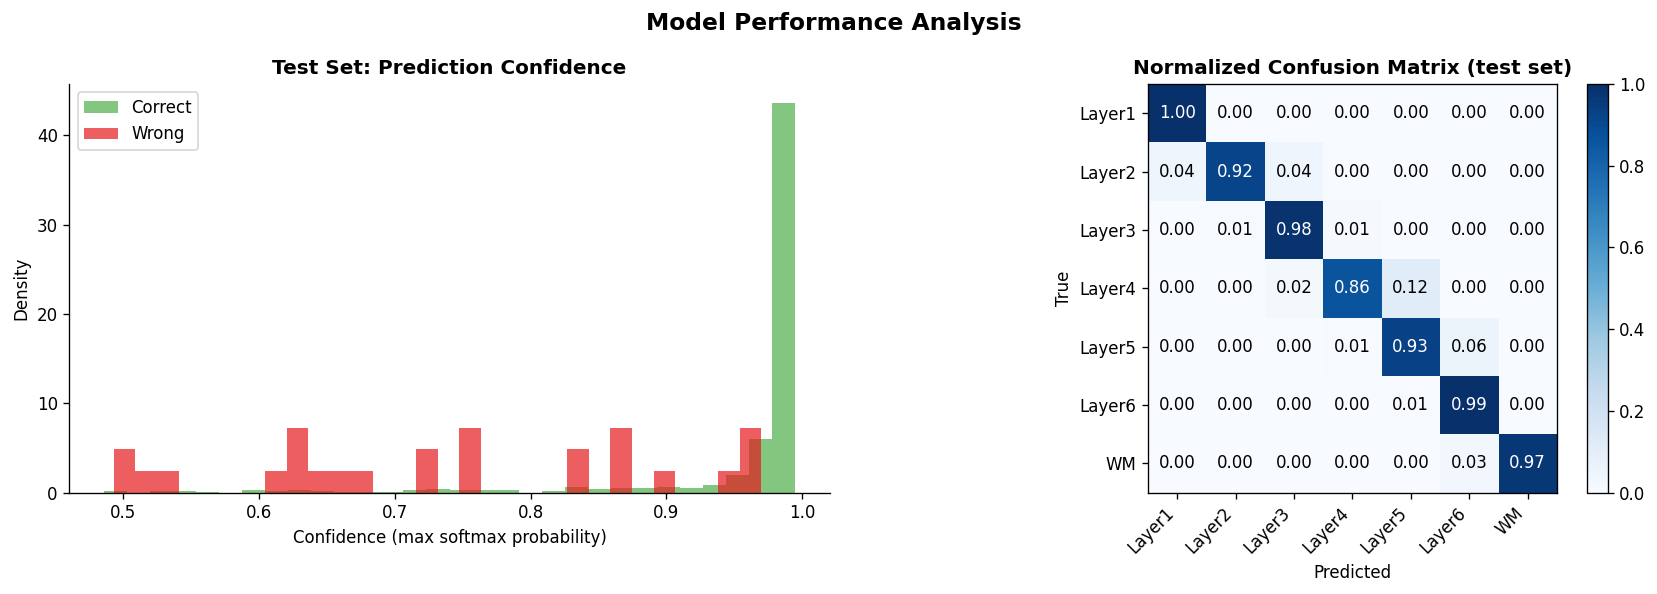

In [11]:
# Model performance analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: confidence histogram (how confident is the model on test spots?)
with torch.no_grad():
    logits_all, _ = model(data.x, data.edge_index)
    probs_all = torch.softmax(logits_all, dim=-1)
    test_probs = probs_all[data.test_mask]
    test_labels = data.y[data.test_mask]
    test_confidence = test_probs.max(dim=1).values.numpy()
    test_correct = (logits_all[data.test_mask].argmax(dim=1) == test_labels).numpy()

axes[0].hist(test_confidence[test_correct], bins=30, alpha=0.7, color='#4DAF4A', label='Correct', density=True)
axes[0].hist(test_confidence[~test_correct], bins=30, alpha=0.7, color='#E41A1C', label='Wrong', density=True)
axes[0].set_title('Test Set: Prediction Confidence', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Confidence (max softmax probability)')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=10)
axes[0].spines['top'].set_visible(False); axes[0].spines['right'].set_visible(False)

# Right: confusion matrix
from sklearn.metrics import confusion_matrix
test_preds = logits_all[data.test_mask].argmax(dim=1).numpy()
cm = confusion_matrix(test_labels.numpy(), test_preds, normalize='true')
im = axes[1].imshow(cm, cmap='Blues', vmin=0, vmax=1)
axes[1].set_title('Normalized Confusion Matrix (test set)', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(n_classes)); axes[1].set_xticklabels(DOMAIN_NAMES, rotation=45, ha='right')
axes[1].set_yticks(range(n_classes)); axes[1].set_yticklabels(DOMAIN_NAMES)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
for i in range(n_classes):
    for j in range(n_classes):
        axes[1].text(j, i, f'{cm[i,j]:.2f}', ha='center', va='center',
                     color='white' if cm[i,j] > 0.5 else 'black', fontsize=10)
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.suptitle('Model Performance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Reading the plots above

**Left (confidence histogram)**:
- **Green bars (correct predictions)**: Should be concentrated at high confidence (>0.8). This means the model is both right *and* sure about it.
- **Red bars (wrong predictions)**: Ideally at lower confidence -- the model is uncertain when it's wrong. If wrong predictions are also high-confidence, the model is overconfident (a calibration problem).

**Right (confusion matrix)**:
- Each cell shows the fraction of true class X predicted as class Y. The diagonal should be bright (high accuracy per class).
- Off-diagonal values reveal systematic errors. Common pattern: confusion between **adjacent layers** (Layer 2 and 3, Layer 5 and 6) because they share spatial boundaries and similar expression profiles.
- The class weighting ensures minority classes (Layer4) are not sacrificed for majority classes (Layer3).

---
# 6. Summary: The Full Forward Pass

```
Input: gene expression (3611 x 3000) + spatial graph (21666 edges)
                    |
    +---------------+---------------+
    |                               |
Expression Encoder (MLP)            |
3000 -> LayerNorm                   |
     -> Linear(3000->256) + GELU    |
     -> Linear(256->128)            |
    |                               |
    +-- Expression Embedding -------+
    |   (3611 x 128)                |
    |                               |
Spatial Encoder (GAT)               |
2 x GATConv(128->128, 4 heads)     |
    + LayerNorm + ELU + Residual    |
    |                               |
    +-- Spatial Embedding           |
    |   (3611 x 128)                |
    |                               |
Cross-Attention Fusion <------------+
Q=Expression, K/V=Spatial neighbors
2 x (MultiheadAttn + FFN + Residual + LayerNorm)
    |
    +-- Fused Embedding
    |   (3611 x 128)
    |
Classifier: Linear(128->7)
    |
    +-- Logits (3611 x 7) -> argmax -> Predictions

Total: ~1.1M parameters | <30s training per slice | 0.926 ARI
```

### Key design principles

1. **Two complementary streams**: Expression captures molecular identity, spatial captures neighborhood context. Neither alone is sufficient.
2. **Attention everywhere**: GAT uses attention for neighbor aggregation, cross-attention uses it for fusion. The model learns *what to pay attention to* at every level.
3. **Residual connections throughout**: Both GAT and cross-attention use skip connections, preventing gradient degradation and allowing the model to preserve information from earlier layers.
4. **Simple classifier on top**: All representational learning happens in the embedding -- the classifier is just a linear probe. This is a sign of good representation learning.